# Timed static frames vs movie window RSA

The 2000-ms frame, the 2250-ms frame, and the last frame were each shown as static images. For every static condition and for the movie:

1. average the response in a half-open window;
2. center every channel across stimuli **after** averaging;
3. build the stimulus RDM from the centered window average.

Each static-frame RDM is correlated with one movie-window RDM. If the movie response in the target window reflects the most recent frame, the correlation should increase from the furthest (2000 ms) to the closest (last) frame.

As a movie-only reference, the same static window is shifted to every frame onset in the movie (frame time + `static_window_ms`), and those movie RDMs are correlated with the same movie target-window RDM. The bar of the last frame is 1 by construction when `movie_window_ms` equals `2500 + static_window_ms`.

In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "config.yaml").is_file()
)
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    paths = yaml.safe_load(file)[ENV]["paths"]
# end with open
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from project_specific_utils.frame_similarity_latency import load_frame_similarity_rasters
from project_specific_utils.timed_frame_window_rsa import (
    compute_dynamic_split_half_window_rsa,
    compute_timed_frame_window_rsa,
    load_dynamic_presentations,
    plot_sliding_movie_window_rsa,
    plot_timed_frame_window_rsa,
    sliding_movie_window_rsa,
)

In [2]:
@dataclass
class Cfg:
    static_exp_name: str = "baby1_260718to27" #  "paul_20260901to0925" #"red_20260726to0925" # 
    dynamic_exp_name: str = "baby1_260716to24" # "paul_20260831to0927" #"red_20260720to0927" # 
    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = (84, 186) #(1, 64) # None # 
    use_reliable_channels: bool = True
    reliable_channels_key: str | None = None #"paul_20260901to0923" #"red_20260726to0923" #"paul_20260901to0923" #None  # None uses static_exp_name, e.g. 
    source_fs: float = 1000
    neural_fs: float = 100

    # Half-open windows: static window from image onset, movie window from movie onset.
    static_window_ms: tuple[float, float] = (80, 250)
    movie_window_ms: tuple[float, float] = (2580, 2750)
    # Movie time at which every static frame appears.
    frame_times_ms: tuple[tuple[str, float], ...] = (
        ("2000ms", 2000), ("2250ms", 2250), ("last_frame", 2500),
    )
    # Centering is done explicitly, so plain cosine equals cosine_cnt here.
    rdm_metric: str = "cosine"
    similarity_metric: str = "spearman"
    n_bootstraps: int = 1000
    seed: int = 0
    # Random repetition splits for the within-movie split-half panel.
    n_split_repeats: int = 100
    # None, "spearman_brown" (2r / (1 + r)), or "noise_ceiling" (r / sqrt(rel_frame * rel_target), half-vs-half rel).
    split_correction: str | None = "noise_ceiling"
    # Sliding movie windows use the static window width.
    sliding_step_ms: float = 10

    save_figures: bool = False
    figure_dpi: int = 160
# EOC

cfg = Cfg()
cfg

Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', good_channels=(84, 186), use_reliable_channels=True, reliable_channels_key=None, source_fs=1000, neural_fs=100, static_window_ms=(80, 250), movie_window_ms=(2580, 2750), frame_times_ms=(('2000ms', 2000), ('2250ms', 2250), ('last_frame', 2500)), rdm_metric='cosine', similarity_metric='spearman', n_bootstraps=1000, seed=0, n_split_repeats=100, sliding_step_ms=10, save_figures=False, figure_dpi=160)

## Load and align the static frames and the movie

In [3]:
data_dir = Path(paths["data_path"]) / "data"
output_dir = PROJECT_ROOT / "results" / "timed_frame_window_rsa" / cfg.static_exp_name

data = load_frame_similarity_rasters(
    data_dir / f"{cfg.static_exp_name}_natraster_img.mat",
    data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat",
    source_fs=cfg.source_fs, new_fs=cfg.neural_fs,
    good_channels=cfg.good_channels,
    reliable_channels_config=(
        PROJECT_ROOT / "reliable_channels.yaml" if cfg.use_reliable_channels else None
    ),
    reliable_channels_key=cfg.reliable_channels_key or cfg.static_exp_name,
    # No per-timepoint centering: centering happens after window averaging.
    center_neural_trials=False,
)
print(f"{data['stimuli'].size} stimuli | {data['dynamic'].shape[0]} channels")

100 stimuli | 30 channels


## Static frames vs movie window

Left: each static-frame RDM vs the movie target-window RDM. Middle: the movie RDM in the frame-aligned windows vs the same movie target-window RDM. Error bars are 95% stimulus-bootstrap intervals. Right: RDM correlations among all six window RDMs.

Third panel (split-half): movie repetitions are split into two random halves; the frame-aligned window RDM of one half is correlated with the target-window RDM of the other half (both directions averaged), over `n_split_repeats` splits. The last bar is now the split-half reliability of the target RDM rather than 1. Error bars are the 95% range across splits. `split_correction` optionally undoes the half-data attenuation: `spearman_brown` applies 2r/(1+r) to every bar; `noise_ceiling` divides by √(rel_frame · rel_target), the half-vs-half RDM reliabilities of the two windows (classic disattenuation), so the target bar is 1.

In [6]:
rsa = compute_timed_frame_window_rsa(
    data,
    static_window_ms=cfg.static_window_ms,
    movie_window_ms=cfg.movie_window_ms,
    frame_times_ms=dict(cfg.frame_times_ms),
    rdm_metric=cfg.rdm_metric,
    similarity_metric=cfg.similarity_metric,
    n_bootstraps=cfg.n_bootstraps,
    seed=cfg.seed,
)
for frame, static_r, movie_r in zip(rsa["frame_names"], rsa["static_movie_r"], rsa["movie_movie_r"]):
    print(f"{frame:>10} | static vs movie r={static_r:.3f} | movie {rsa['aligned_movie_windows'][frame]} vs movie r={movie_r:.3f}")
# end for frame

# Bootstrap probability that every closer frame beats the preceding one.
bootstrap_r = rsa["static_bootstrap_r"]
for earlier, later in zip(range(len(rsa["frame_names"]) - 1), range(1, len(rsa["frame_names"]))):
    probability = np.mean(bootstrap_r[:, later] > bootstrap_r[:, earlier])
    print(f"P(r {rsa['frame_names'][later]} > r {rsa['frame_names'][earlier]}) = {probability:.3f}")
# end for earlier, later

# Single movie presentations, same channels and stimuli, up to the last needed window.
last_window_end_ms = max(
    cfg.movie_window_ms[1], *(end for _, end in rsa["aligned_movie_windows"].values()),
)
dynamic_presentations, dynamic_identities = load_dynamic_presentations(
    data_dir / f"{cfg.dynamic_exp_name}_raster_vid.mat", data, last_window_end_ms,
    source_fs=cfg.source_fs,
)
split_rsa = compute_dynamic_split_half_window_rsa(
    dynamic_presentations, dynamic_identities, rsa, data["stimuli"], data["neural_fs"],
    n_split_repeats=cfg.n_split_repeats, seed=cfg.seed, correction=cfg.split_correction,
)
print(f"target window reliability (Spearman-Brown) = {np.mean(split_rsa['target_reliability']):.3f}")
for frame_index, frame in enumerate(rsa["frame_names"]):
    print(
        f"{frame:>10} | split-half movie {rsa['aligned_movie_windows'][frame]} vs movie "
        f"raw r={split_rsa['raw_split_r'][:, frame_index].mean():.3f} | "
        f"{cfg.split_correction} r={split_rsa['mean_r'][frame_index]:.3f} | "
        f"window reliability={split_rsa['frame_reliability'][:, frame_index].mean():.3f}"
    )
# end for frame_index

bar_figure, _ = plot_timed_frame_window_rsa(rsa, cfg.static_exp_name, split_rsa)
plt.show()

    2000ms | static vs movie r=0.105 | movie (2080, 2250) vs movie r=0.236
    2250ms | static vs movie r=0.252 | movie (2330, 2500) vs movie r=0.596
last_frame | static vs movie r=0.595 | movie (2580, 2750) vs movie r=1.000
P(r 2250ms > r 2000ms) = 0.998
P(r last_frame > r 2250ms) = 1.000


AttributeError: 'Cfg' object has no attribute 'split_correction'

## Sliding movie window

The movie window (same width as `static_window_ms`) slides over the whole movie; every static-frame RDM is correlated with the movie RDM at each position. Dashed lines mark the frame onsets; the orange band is `movie_window_ms`. Reading the curves vertically inside the band gives the bars above.

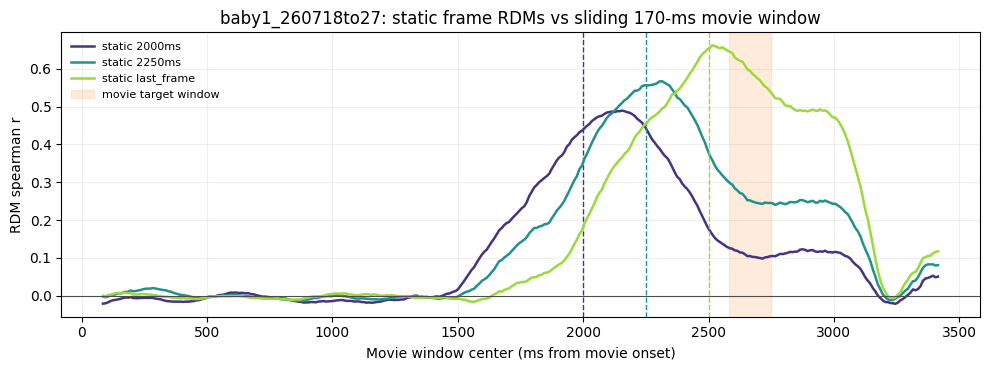

In [5]:
window_width_ms = cfg.static_window_ms[1] - cfg.static_window_ms[0]
window_centers_ms, sliding_curves = sliding_movie_window_rsa(
    data, rsa["static_rdms"], window_width_ms, cfg.sliding_step_ms,
    rdm_metric=cfg.rdm_metric, similarity_metric=cfg.similarity_metric,
)
sliding_figure, _ = plot_sliding_movie_window_rsa(
    window_centers_ms, sliding_curves, rsa,
    title=f"{cfg.static_exp_name}: static frame RDMs vs sliding {window_width_ms:g}-ms movie window",
)
if cfg.save_figures:
    output_dir.mkdir(parents=True, exist_ok=True)
    bar_figure.savefig(output_dir / "timed_frame_window_rsa.png", dpi=cfg.figure_dpi, bbox_inches="tight")
    sliding_figure.savefig(output_dir / "sliding_movie_window_rsa.png", dpi=cfg.figure_dpi, bbox_inches="tight")
# end if cfg.save_figures
plt.show()